In [1]:
#importing necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [2]:
#loading dataset
df = pd.read_csv("../Data/EstateProductivityPrediction_dataset.CSV")

In [3]:
#Exploratary data analysis (EDA)
df.head(30)

,year,month,month_num,wet_days,rainfall,male_workforce,female_workforce,temperature_T2M,irradiance_SW_DWN,yield
0,2016,April,4,9.0,163.0,396.0,505.0,25.00,6.1423,NaN
1,2016,May,5,28.0,1352.0,NaN,NaN,24.05,4.2475,NaN
2,2016,June,6,24.0,631.0,NaN,NaN,22.86,5.0206,NaN
3,2016,July,7,18.0,448.0,NaN,NaN,22.51,5.0669,NaN
4,2016,August,8,20.0,614.0,NaN,NaN,22.76,5.1598,NaN
5,2016,September,9,11.0,160.0,NaN,NaN,22.71,5.4122,NaN
6,2016,October,10,16.0,444.0,NaN,NaN,23.06,5.3230,NaN
7,2016,November,11,16.0,577.0,NaN,NaN,22.37,4.1700,NaN
8,2016,December,12,3.0,151.0,NaN,NaN,21.75,4.9634,NaN
9,2017,January,1,7.0,99.0,NaN,NaN,21.26,5.1437,NaN


In [4]:
df.shape

(115, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               115 non-null    int64  
 1   month              115 non-null    object 
 2   month_num          115 non-null    int64  
 3   wet_days           109 non-null    float64
 4   rainfall           109 non-null    float64
 5   male_workforce     10 non-null     float64
 6   female_workforce   10 non-null     float64
 7   temperature_T2M    115 non-null    float64
 8   irradiance_SW_DWN  115 non-null    float64
 9   yield              96 non-null     float64
dtypes: float64(7), int64(2), object(1)
memory usage: 9.1+ KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,115.0,2020.539130,2.791865,2016.00,2018.00000,2021.0000,2023.00000,2025.0000
month_num,115.0,6.530435,3.398456,1.00,4.00000,7.0000,9.00000,12.0000
wet_days,109.0,16.642202,7.167988,2.00,11.00000,17.0000,23.00000,30.0000
rainfall,109.0,469.568807,336.178534,41.00,202.00000,428.0000,674.00000,1393.0000
male_workforce,10.0,277.900000,84.848165,157.00,208.75000,292.0000,339.75000,396.0000
female_workforce,10.0,365.100000,105.687643,208.00,293.25000,377.5000,439.25000,505.0000
temperature_T2M,115.0,22.834696,0.890510,20.51,22.34500,22.8000,23.37500,25.2700
irradiance_SW_DWN,115.0,-3.692816,93.628713,-999.00,4.68375,4.9622,5.47815,6.3634
yield,96.0,43301.218750,14153.937309,16821.00,33286.25000,41087.0000,51588.25000,88699.0000


In [7]:
df.describe(include="object").T

,count,unique,top,freq
month,115,12,April,10


In [8]:
#null/missing values
df['irradiance_SW_DWN']= df['irradiance_SW_DWN'].replace(-999, np.nan)   #sentinal value
df.isnull().sum()

year                   0
month                  0
month_num              0
wet_days               6
rainfall               6
male_workforce       105
female_workforce     105
temperature_T2M        0
irradiance_SW_DWN      1
yield                 19
dtype: int64

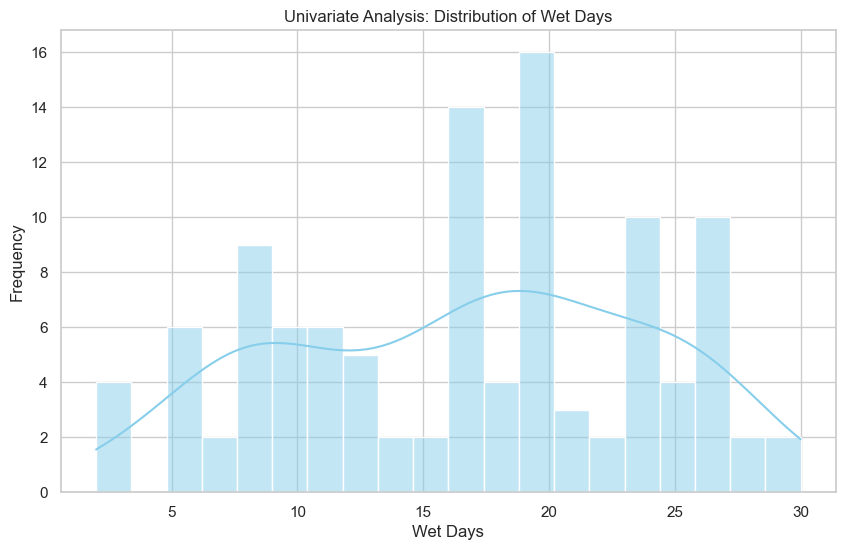

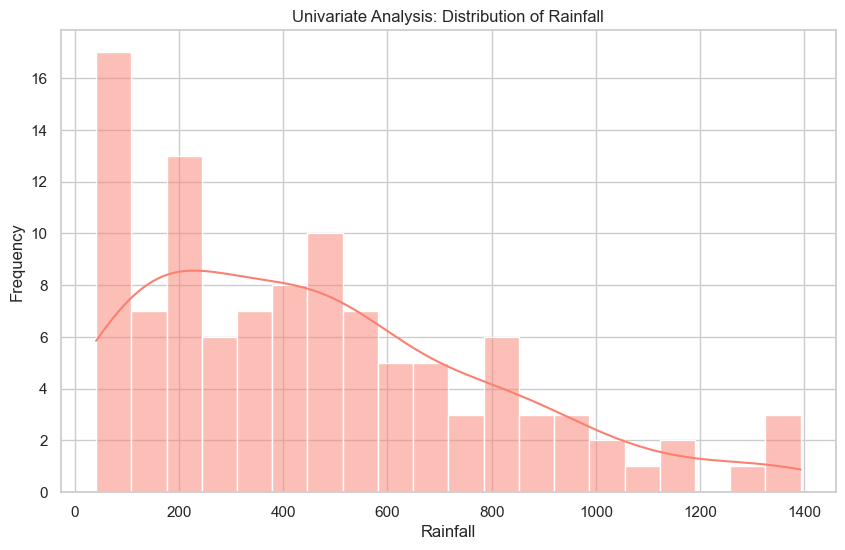

In [9]:
#Handling missing values

#plotting the features to understand better

#Set the visual style
sns.set_theme(style="whitegrid")

#Plot Histogram for 'wet_days'
plt.figure(figsize=(10, 6))
sns.histplot(df['wet_days'].dropna(), kde=True, color='skyblue', bins=20)
plt.title('Univariate Analysis: Distribution of Wet Days')
plt.xlabel('Wet Days')
plt.ylabel('Frequency')
plt.show()

#Plot Histogram for 'rainfall'
plt.figure(figsize=(10, 6))
sns.histplot(df['rainfall'].dropna(), kde=True, color='salmon', bins=20)
plt.title('Univariate Analysis: Distribution of Rainfall')
plt.xlabel('Rainfall')
plt.ylabel('Frequency')
plt.show()

In [10]:
#handling missing values of the rainfall and wet days column
df['rainfall']=(df.groupby('month')['rainfall'].transform(lambda x: x.fillna(x.median())))         #median because rainfall is skewed

df['wet_days']=(df.groupby('month')['wet_days'].transform(lambda x: x.fillna(x.mean())))

# Month-wise MEDIAN imputation for yield-you can try out imputation by using knn, interpolation (forward and backward fill)
df['yield'] = (
    df.groupby('month')['yield']
      .transform(lambda x: x.fillna(x.median()))
)

#handling missing values in labour data
df['male_workforce']= (df.groupby('year')['male_workforce'].transform(lambda x: x.fillna(x.dropna().iloc[0])))

df['female_workforce']= (df.groupby('year')['female_workforce'].transform(lambda x: x.fillna(x.dropna().iloc[0])))

#sentinal value in shortwave irradiance
df['irradiance_SW_DWN']=(df.groupby('month')['irradiance_SW_DWN'].transform(lambda x: x.fillna(x.median())))

# Final check
df.isnull().sum()

year                 0
month                0
month_num            0
wet_days             0
rainfall             0
male_workforce       0
female_workforce     0
temperature_T2M      0
irradiance_SW_DWN    0
yield                0
dtype: int64

In [11]:
#duplicate records
print('Number of Duplicate Records: ',df.duplicated().sum())

Number of Duplicate Records:  0


In [12]:
#checking for structural errors/incorrect naming conventions
df['month'].unique()

array(['April', 'May', 'June', 'July', 'August', 'September', 'October',
       'November', 'December', 'January', 'February', 'March'],
      dtype=object)

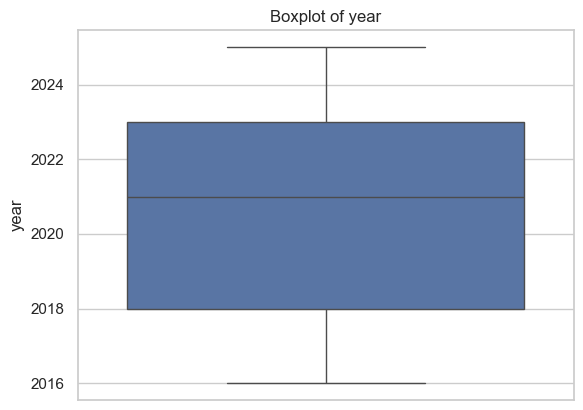

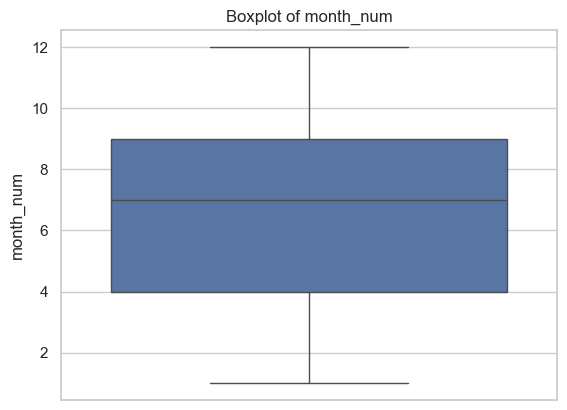

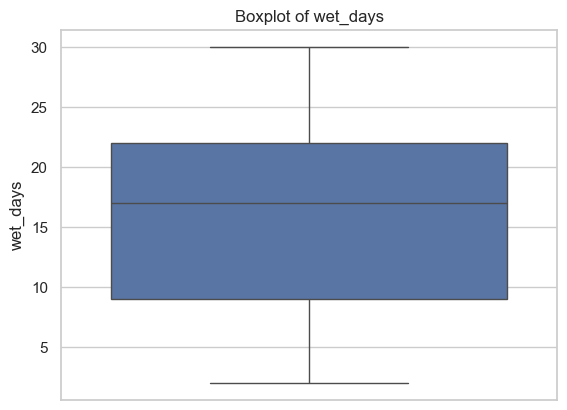

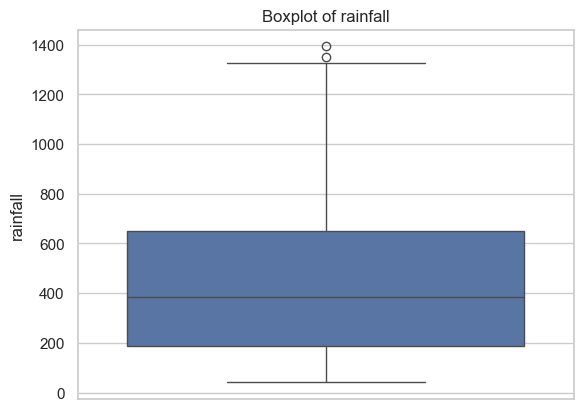

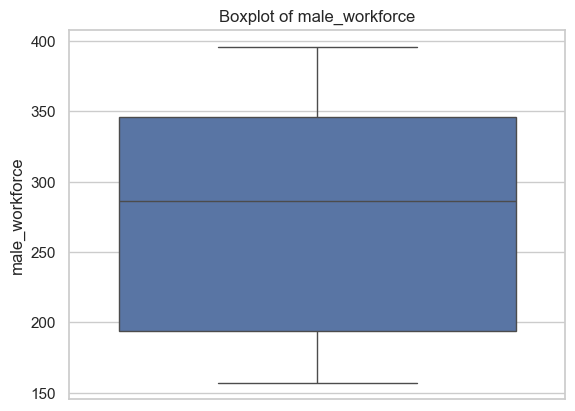

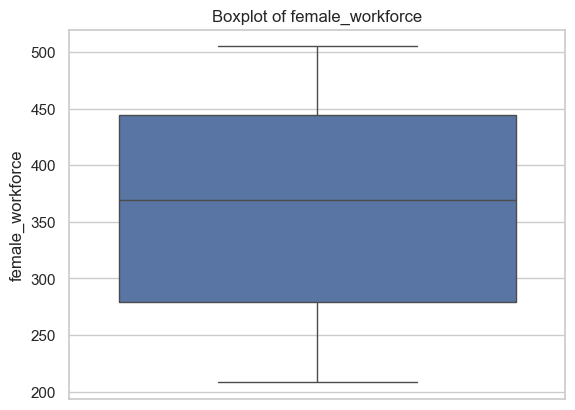

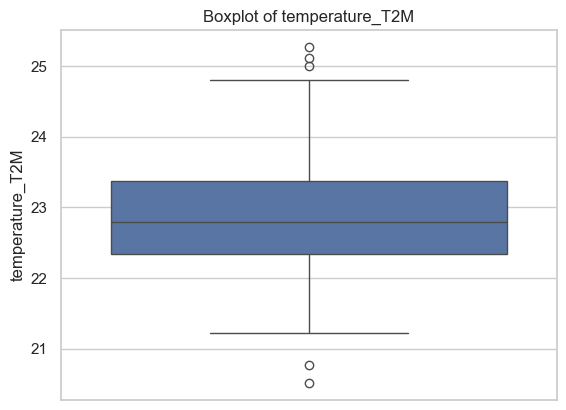

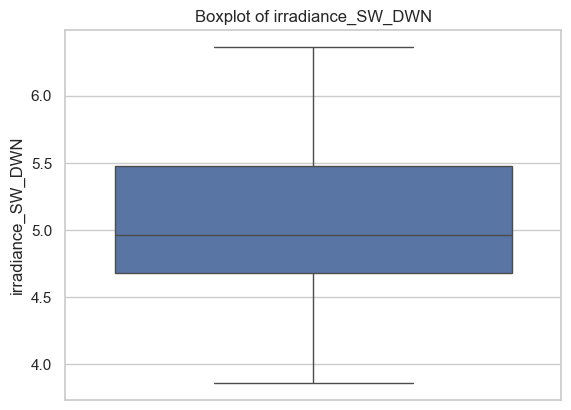

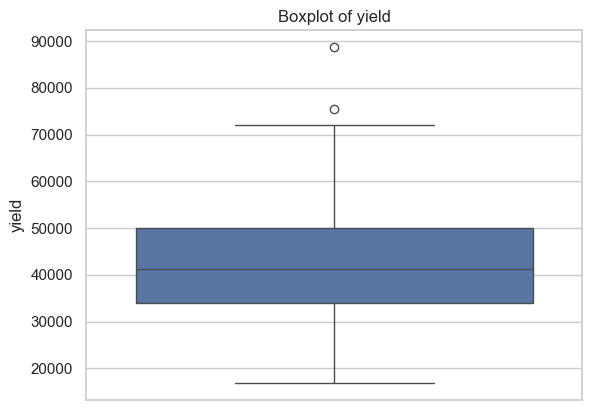

In [13]:
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    sns.boxplot(data=df,y=col)
    plt.title(f"Boxplot of {col}")
    plt.show()

In [14]:
df[df['yield']>75000]  #yield outliers will be kept as it is since these are likely to be real values

,year,month,month_num,wet_days,rainfall,male_workforce,female_workforce,temperature_T2M,irradiance_SW_DWN,yield
12,2017,April,4,15.222222,349.0,367.0,486.0,24.37,6.0929,75563.0
30,2018,October,10,24.000000,480.0,346.0,444.0,22.56,4.5480,88699.0


In [15]:
#handling outliers-rainfall
df[df['rainfall']>1350]    #keeping rainfall outliers because they are most likely accurate

,year,month,month_num,wet_days,rainfall,male_workforce,female_workforce,temperature_T2M,irradiance_SW_DWN,yield
1,2016,May,5,28.0,1352.0,396.0,505.0,24.05,4.2475,63661.0
76,2022,August,8,20.0,1393.0,253.0,336.0,22.30,4.8590,16821.0


In [16]:
#t2M
df[(df['temperature_T2M']>=25) | (df['temperature_T2M']<21)] #keeping temperature outliers because they are most likely accurate

,year,month,month_num,wet_days,rainfall,male_workforce,female_workforce,temperature_T2M,irradiance_SW_DWN,yield
0,2016,April,4,9.0,163.0,396.0,505.0,25.00,6.1423,42719.0
21,2018,January,1,5.0,46.0,346.0,444.0,20.77,5.2495,61705.0
36,2019,April,4,16.0,349.0,321.0,425.0,25.11,5.4701,40691.0
81,2023,January,1,8.0,58.0,194.0,279.0,20.51,4.8403,31728.0
96,2024,April,4,6.0,41.0,157.0,213.0,25.27,5.6359,24741.0


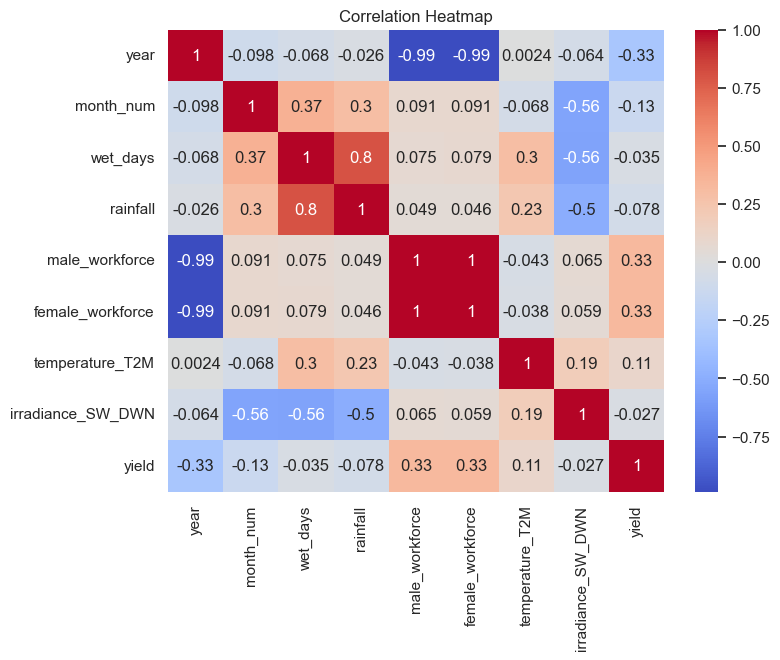

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title('Correlation Heatmap')
plt.show()

In [18]:
#handling correlation between male and female workforce

#creatine a total workforce column
df['total_workforce']=df['female_workforce']+df['male_workforce']

#creating female workforce as a ratio
df['female_workforceRatio']=df['female_workforce']/df['total_workforce']

df.drop(['male_workforce','female_workforce'], axis=1, inplace=True)

# Quick verification
print(df[['total_workforce', 'female_workforceRatio']].head())

   total_workforce  female_workforceRatio
0            901.0               0.560488
1            901.0               0.560488
2            901.0               0.560488
3            901.0               0.560488
4            901.0               0.560488


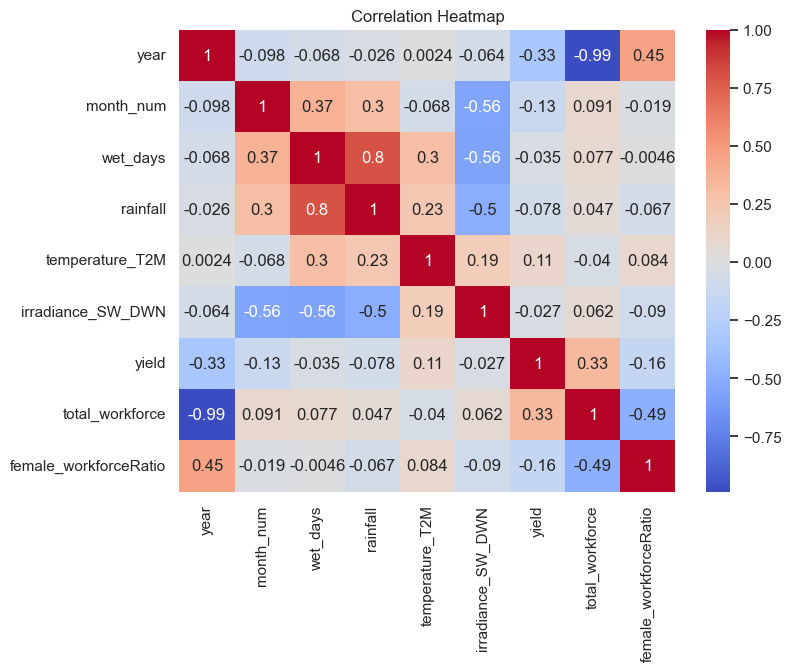

In [19]:
num_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title('Correlation Heatmap')
plt.show()

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   year                   115 non-null    int64  
 1   month                  115 non-null    object 
 2   month_num              115 non-null    int64  
 3   wet_days               115 non-null    float64
 4   rainfall               115 non-null    float64
 5   temperature_T2M        115 non-null    float64
 6   irradiance_SW_DWN      115 non-null    float64
 7   yield                  115 non-null    float64
 8   total_workforce        115 non-null    float64
 9   female_workforceRatio  115 non-null    float64
dtypes: float64(7), int64(2), object(1)
memory usage: 9.1+ KB


In [21]:
#adding lags
df = df.sort_values(['year', 'month_num']).reset_index(drop=True)
df['yield_lag_1']=df['yield'].shift(1)
df['yield_lag_2']=df['yield'].shift(2)
df['yield_lag_3']=df['yield'].shift(3)

#rainfall lag
df['rainfall_lag_1']= df['rainfall'].shift(1)

#remove rows with missing lags
df=df.dropna().reset_index(drop=True)

In [22]:
df.head(10)

,year,month,month_num,wet_days,rainfall,temperature_T2M,irradiance_SW_DWN,yield,total_workforce,female_workforceRatio,yield_lag_1,yield_lag_2,yield_lag_3,rainfall_lag_1
0,2016,July,7,18.000000,448.0,22.51,5.0669,47718.5,901.0,0.560488,38829.0,63661.0,42719.0,631.0
1,2016,August,8,20.000000,614.0,22.76,5.1598,25772.5,901.0,0.560488,47718.5,38829.0,63661.0,448.0
2,2016,September,9,11.000000,160.0,22.71,5.4122,35421.0,901.0,0.560488,25772.5,47718.5,38829.0,614.0
3,2016,October,10,16.000000,444.0,23.06,5.3230,33194.0,901.0,0.560488,35421.0,25772.5,47718.5,160.0
4,2016,November,11,16.000000,577.0,22.37,4.1700,44693.0,901.0,0.560488,33194.0,35421.0,25772.5,444.0
5,2016,December,12,3.000000,151.0,21.75,4.9634,50271.0,901.0,0.560488,44693.0,33194.0,35421.0,577.0
6,2017,January,1,7.000000,99.0,21.26,5.1437,48936.5,853.0,0.569754,50271.0,44693.0,33194.0,151.0
7,2017,February,2,6.333333,83.5,22.43,5.6460,40714.5,853.0,0.569754,48936.5,50271.0,44693.0,99.0
8,2017,March,3,18.000000,418.0,23.23,5.8464,45356.0,853.0,0.569754,40714.5,48936.5,50271.0,83.5
9,2017,April,4,15.222222,349.0,24.37,6.0929,75563.0,853.0,0.569754,45356.0,40714.5,48936.5,418.0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   year                   112 non-null    int64  
 1   month                  112 non-null    object 
 2   month_num              112 non-null    int64  
 3   wet_days               112 non-null    float64
 4   rainfall               112 non-null    float64
 5   temperature_T2M        112 non-null    float64
 6   irradiance_SW_DWN      112 non-null    float64
 7   yield                  112 non-null    float64
 8   total_workforce        112 non-null    float64
 9   female_workforceRatio  112 non-null    float64
 10  yield_lag_1            112 non-null    float64
 11  yield_lag_2            112 non-null    float64
 12  yield_lag_3            112 non-null    float64
 13  rainfall_lag_1         112 non-null    float64
dtypes: float64(11), int64(2), object(1)
memory usage: 12.4+ KB

In [24]:
features = ['rainfall','wet_days','temperature_T2M','irradiance_SW_DWN','total_workforce','female_workforceRatio','yield_lag_1','yield_lag_2','yield_lag_3','rainfall_lag_1']

target = ['yield']
X=df[features]
Y=df[target]

In [25]:
split_idx=int(len(df)*0.8)
x_train = X.iloc[:split_idx]
y_train = Y.iloc[:split_idx]

x_test = X.iloc[split_idx:]
y_test = Y.iloc[split_idx:]


In [26]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(x_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [27]:
y_pred = xgb_model.predict(x_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("Model A — XGBoost Yield Prediction")
print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"R²  : {r2:.3f}")

Model A — XGBoost Yield Prediction
RMSE: 11694.02
MAE : 9216.62
R²  : -0.530


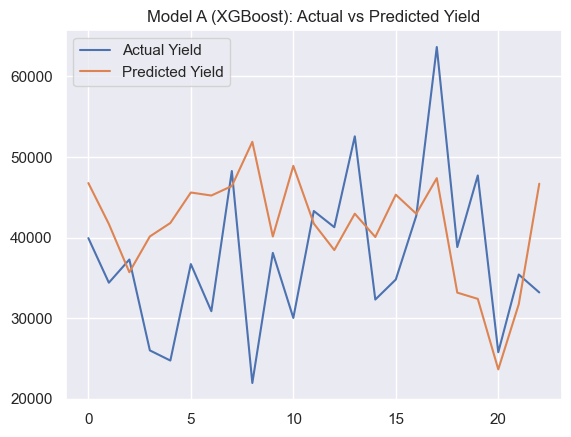

In [28]:
plt.figure()
plt.plot(y_test.values, label="Actual Yield")
plt.plot(y_pred, label="Predicted Yield")
plt.legend()
plt.title("Model A (XGBoost): Actual vs Predicted Yield")
plt.show()


In [29]:
x_train.index.equals(y_train.index)
x_test.index.equals(y_test.index)



True

In [30]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train, y_train)
pred = lr.predict(x_test)

print(r2_score(y_test, pred))


-0.6767635170943394


In [31]:
mean_pred = np.repeat(y_train.mean(), len(y_test))
print("Mean baseline R²:", r2_score(y_test, mean_pred))


Mean baseline R²: -0.5585069310978066
